In [123]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
from pathlib import Path
import joblib 


# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [143]:
data_dir = '/Users/mghrear/data/HPS_data/2021_v9_pass5_preds/'


bdt_selection = 0.528
bdt_selection_sideband_a = 0.525
bdt_selection_sideband_b  = 0.511

ann_selection = 0.9324
ann_selection_sideband_a = 0.649
ann_selection_sideband_b = 0.684


bdt_InvMs = np.array([])
bdt_InvMs_sideband_a = np.array([])
bdt_InvMs_sideband_b = np.array([])
ann_InvMs = np.array([])
ann_InvMs_sideband_a = np.array([])
ann_InvMs_sideband_b= np.array([])


for p in Path(data_dir).iterdir():

    # Load dataframe
    df = pd.read_pickle(data_dir+p.name)

    # Add positron cluster energy filter
    df = df.loc[df.pos_E_Ecal > 0.6]

    # Make selections
    df_bdt = df.loc[df.bdt_model_pred > bdt_selection]
    df_bdt_sideband_a = df.loc[df.bdt_model_pred_sideband_a > bdt_selection_sideband_a]
    df_bdt_sideband_b = df.loc[df.bdt_model_pred_sideband_b > bdt_selection_sideband_b]

    df_ann = df.loc[df.ANN_pred > ann_selection]
    df_ann_sideband_a = df.loc[df.ANN_pred_sideband_a > ann_selection_sideband_a]
    df_ann_sideband_b = df.loc[df.ANN_pred_sideband_b > ann_selection_sideband_b]

    # Calculate invariant mass
    bdt_InvMs = np.concatenate((bdt_InvMs,mytools.get_InvM(df_bdt)))
    bdt_InvMs_sideband_a = np.concatenate((bdt_InvMs_sideband_a,mytools.get_InvM(df_bdt_sideband_a)))
    bdt_InvMs_sideband_b = np.concatenate((bdt_InvMs_sideband_b,mytools.get_InvM(df_bdt_sideband_b)))

    ann_InvMs = np.concatenate((ann_InvMs,mytools.get_InvM(df_ann)))
    ann_InvMs_sideband_a = np.concatenate((ann_InvMs_sideband_a,mytools.get_InvM(df_ann_sideband_a)))
    ann_InvMs_sideband_b = np.concatenate((ann_InvMs_sideband_b,mytools.get_InvM(df_ann_sideband_b)))




# BDT

418126


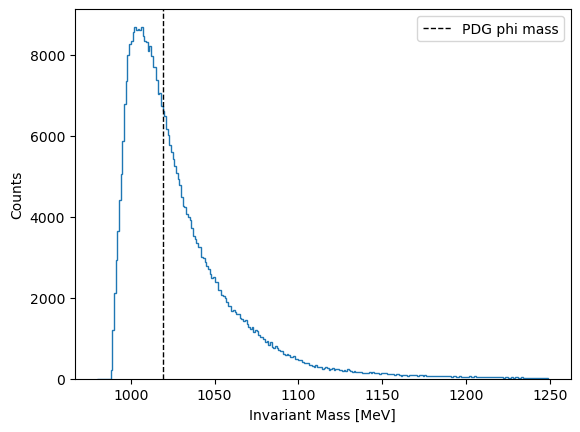

In [144]:
print(len(bdt_InvMs))


plt.hist(1000*bdt_InvMs, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()


388195


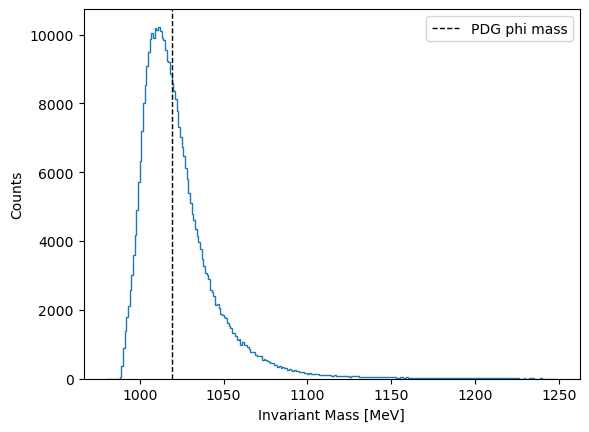

In [145]:
print(len(bdt_InvMs_sideband_a))


plt.hist(1000*bdt_InvMs_sideband_a, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()


467344


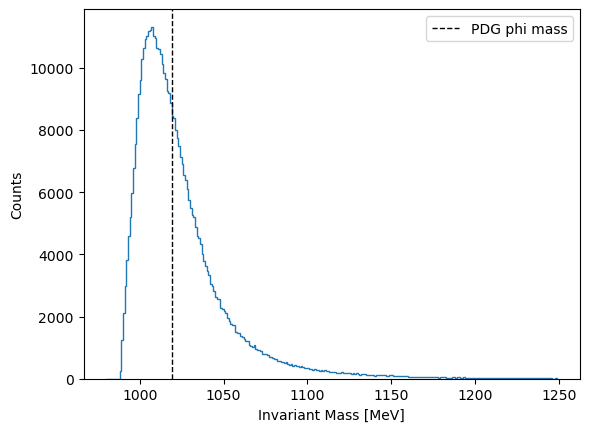

In [146]:
print(len(bdt_InvMs_sideband_b))


plt.hist(1000*bdt_InvMs_sideband_b, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()


# ANN

421586


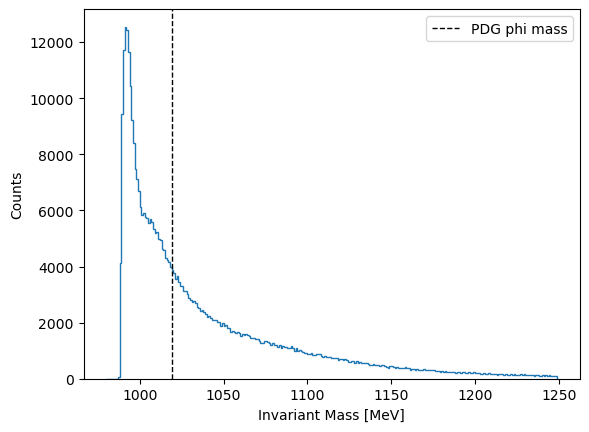

In [147]:
print(len(ann_InvMs))

plt.hist(1000*ann_InvMs, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()


931598


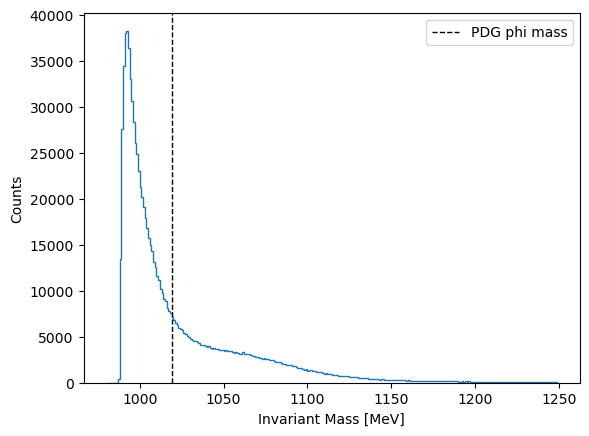

In [148]:
print(len(ann_InvMs_sideband_b))

plt.hist(1000*ann_InvMs_sideband_b, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()


931598


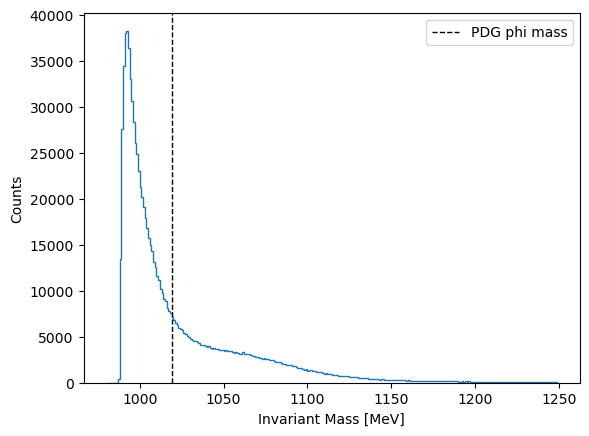

In [149]:
print(len(ann_InvMs_sideband_b))

plt.hist(1000*ann_InvMs_sideband_b, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()
